# preprocessing

The image processing step (input: raw images, output: fitted bright spots) can be found in github::ecDNATracer (add link).

Once we have fitted the fitted bright spots, we use that as input to the ecDNATracer, which outputs assembled ecDNA/chr7_endogenous traces. An example can be found in github::ecDNATracer (add link.)

For this script, we will start from the assmbled traces.

Relevant figures can be found in Figure 1, Extended Data Figure 2

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import sys

In [14]:
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

# GBM39 in vitro replicate 1

## load traces

In [18]:
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___invitro_03012025\BT__preEM_strict_redooffby1_31FOVs__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
BT_linear_traces, BT_circ_traces = dic_linear_circ_by_type[tr_type]
BT_linear_traces.shape, BT_circ_traces.shape

((849, 252, 6), (35969, 252, 6))

## compute detection efficiency

In [17]:
def compute_detection_eff(traces):
    detected = np.isfinite(traces)
    det_eff = detected.mean(axis=(0, 2))
    return det_eff

In [19]:
BT_det_eff_linear = compute_detection_eff(BT_linear_traces)
BT_det_eff_circ = compute_detection_eff(BT_circ_traces)

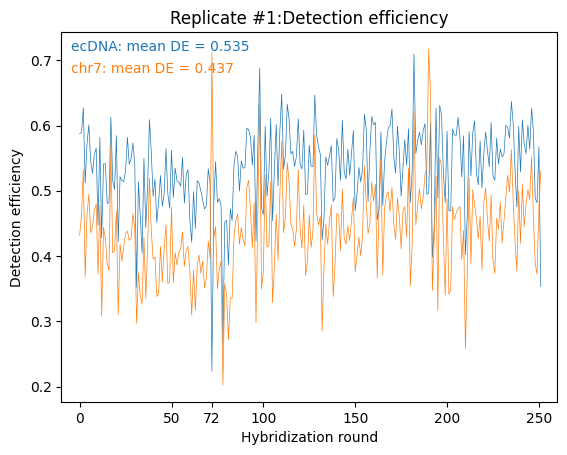

In [20]:
fig, ax = plt.subplots()

ax.plot(BT_det_eff_circ, color='C0', label='ecDNA', lw = 0.5)
ax.plot(BT_det_eff_linear, color='C1', label='chr7', lw = 0.5)

ax.set_xlabel('Hybridization round')
ax.set_ylabel('Detection efficiency')
ax.set_title('Replicate #1:Detection efficiency')

# x range
ax.set_xlim(0, 260)

# mean detection efficiencies
mean_circ = np.nanmean(BT_det_eff_circ)
mean_lin  = np.nanmean(BT_det_eff_linear)

# colored annotation (top-left)
ax.text(
    0.02, 0.98,
    f"ecDNA: mean DE = {mean_circ:.3f}",
    transform=ax.transAxes,
    ha='left', va='top',
    color='C0'
)
ax.text(
    0.02, 0.92,
    f"chr7: mean DE = {mean_lin:.3f}",
    transform=ax.transAxes,
    ha='left', va='top',
    color='C1'
)

# custom tick at 72
xticks = ax.get_xticks()
if 72 not in xticks:
    ax.set_xticks(sorted(np.append(xticks, 72)))
    

# remove legend
ax.legend().remove()

ax.set_xlim((-10, 260))
ax.margins(x=0)

# fig.savefig("C:/GBM39/manuscript_figures/extended_invitro_fig1/plots/detect_eff/BT_detection_efficiency.svg", format="svg", bbox_inches="tight")

plt.show()


## comparison with HiC

In [39]:
BT_joint_traces = np.vstack([BT_linear_traces, BT_circ_traces])
BT_joint_meddist = np.nanmedian(compute_med_dist_mat(BT_joint_traces, contact_dist = None), axis = 0)

100%|██████████████████████████████████████████████████████████████████████████| 36818/36818 [00:10<00:00, 3584.13it/s]


### process HiC matrix

The dataset used is from a published dropletHiC dataset

In [52]:
import cooler

In [54]:
clr_fl = 'C:/GBM39/GBM39_HiC/LC499_t2t.mcool'
# Load 5kb resolution from .mcool file
clr = cooler.Cooler(f"{clr_fl}::resolutions/5000")

In [53]:
## load ref coordinates
df_refgen = pd.read_csv('C:/GBM39/design/TulaFFBBL1Library_df_refgen.csv')
start = df_refgen['Name'][0].split('_')[1]
end = df_refgen['Name'][len(df_refgen)-1].split('_')[-1]
ecDNA_t2t_coord = f"chr7:{start}-{end}"
ecDNA_t2t_coord

'chr7:54925183-56212282'

In [55]:
# Now extract the matrix
matrix = clr.matrix(balance=True, sparse=False).fetch(ecDNA_t2t_coord)
matrix = np.array(matrix)

In [56]:
import numpy as np

def reduce_matrix(matrix):
    """
    Removes rows and columns 74-77 and the last row and column from a 258x258 matrix.
    
    Parameters:
        matrix (numpy.ndarray): A 258x258 matrix.
        
    Returns:
        numpy.ndarray: A 252x252 matrix with specified rows and columns removed.
    """
    if matrix.shape != (258, 258):
        raise ValueError("Input matrix must be of shape (258, 258)")

    rows_to_remove = list(range(74, 78)) + [0,257]  # Rows 74-77 and the last row
    cols_to_remove = list(range(74, 78)) + [0,257]  # Columns 74-77 and the last column

    reduced_matrix = np.delete(matrix, rows_to_remove, axis=0)  # Remove rows
    reduced_matrix = np.delete(reduced_matrix, cols_to_remove, axis=1)  # Remove columns

    return reduced_matrix

In [57]:
## save a copy of balanced
bmatrix = clr.matrix(balance=True, sparse=False).fetch(ecDNA_t2t_coord)
bmatrix = np.array(bmatrix)
bred_mat = reduce_matrix(bmatrix)
np.save(r'C:\GBM39\GBM39_HiC\LC499_t2t_ecDNA_hic_balanced.npy', bred_mat)

### plot HiC matrix

In [58]:
hic_mat = np.load('C:/GBM39/GBM39_HiC/LC499_t2t_ecDNA_hic_balanced.npy')
hic_mat.shape

(252, 252)

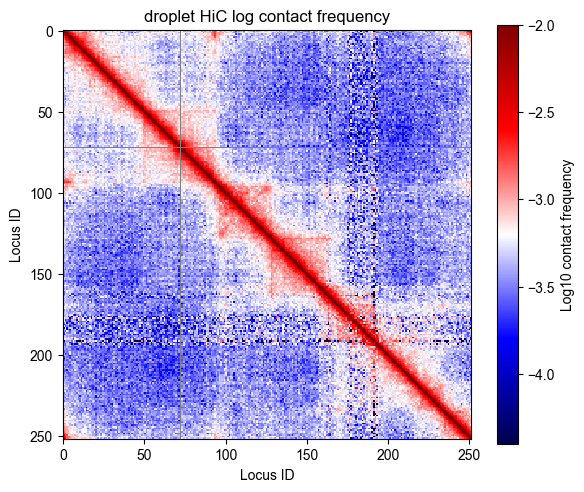

In [59]:
eps = 1e-6
L = np.log10(hic_mat + eps)
# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard
plt.rcParams['font.family'] = 'Arial'



# --- Data & colormap with NaNs as dark gray ---
# M0 = cv2.blur(joint_meddist,(2,2))
M0 = L.copy()
# M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=-2, vmax=-4,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log10 contact frequency')
ax.set_title(f'droplet HiC log contact frequency')

fig.tight_layout()

### plot HiC correlation

In [48]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import pearsonr

def plot_hic_vs_spatial_log10(
    hic_mat: np.ndarray,
    spatial_mat: np.ndarray,
    vmax_dist: int = 120,
    plot_type: str = 'dist',              # 'dist' or anything else -> label tweak
    log: bool = True,                     # log10 axes (actually plotting log10 values)
    s: float = 5,                         # dot size
    alpha: float = 0.8,                   # dot alpha
    cmap: str = 'coolwarm',               # colormap for genomic distance
    svg_path = None,          # e.g., r"C:\path\plot.svg"
    dots_dpi: int = 300,                  # resolution for the rasterized dots
    clip_frac = (0, 1),                   # optional percentile clip on values (0..1, no clip)
    title = None
):
    """
    Scatter Hi-C vs spatial (upper triangle), color-coded by genomic distance.
    If log=True, plots log10(hic) vs log10(spatial) on linear axes and
    computes Pearson r in log10 space.

    Returns
    -------
    fig, ax, pearson_r
    """
    assert hic_mat.shape == spatial_mat.shape, "Hi-C and spatial matrices must have same shape"
    N = hic_mat.shape[0]

    # --- Upper triangle (exclude diagonal) ---
    iu, ju = np.triu_indices(N, k=1)
    hic_vals = hic_mat[iu, ju].astype(float)
    spatial_vals = spatial_mat[iu, ju].astype(float)
    genomic_dists = np.abs(iu - ju)

    # --- Optional percentile clipping on values (helps with extreme outliers) ---
    if clip_frac != (0, 1):
        lo_hic, hi_hic = np.nanpercentile(hic_vals, [100*clip_frac[0], 100*clip_frac[1]])
        lo_spa, hi_spa = np.nanpercentile(spatial_vals, [100*clip_frac[0], 100*clip_frac[1]])
        hic_vals = np.clip(hic_vals, lo_hic, hi_hic)
        spatial_vals = np.clip(spatial_vals, lo_spa, hi_spa)

    # --- Valid mask (and >0 if using log10) ---
    if log:
        valid = (
            np.isfinite(hic_vals) &
            np.isfinite(spatial_vals) &
            (hic_vals > 0) &
            (spatial_vals > 0)
        )
    else:
        valid = np.isfinite(hic_vals) & np.isfinite(spatial_vals)

    hic_vals = hic_vals[valid]
    spatial_vals = spatial_vals[valid]
    genomic_dists = genomic_dists[valid]

    # --- Transform for plotting + Pearson ---
    if log:
        x_plot = np.log10(hic_vals)
        y_plot = np.log10(spatial_vals)
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan
    else:
        x_plot = hic_vals
        y_plot = spatial_vals
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan

    print(f'pearson_pval = {pearson_pval}')
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))
    norm = Normalize(0, vmax_dist)
    sc = ax.scatter(
        x_plot, y_plot,
        c=np.clip(genomic_dists, 0, vmax_dist),
        cmap=cmap, norm=norm,
        s=s, alpha=alpha
    )

    # Rasterize ONLY the scatter dots in the SVG
    sc.set_rasterized(True)

    # axis labels
    ylab = 'pairwise spatial distance (µm)' if plot_type == 'dist' \
           else 'contact freq (<250 nm)'

    if log:
        ax.set_xlabel('log10 Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'log10 Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial (log10–log10)'
    else:
        ax.set_xlabel('Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial'

    ttl = title if title is not None else f'{base_title}\n Pearson r = {pearson_r:.3f}, p = {pearson_pval}'
    ax.set_title(ttl)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Genomic distance (bins)')

    plt.tight_layout()

    # --- Save SVG with editable text, vectors for everything except dots ---
    if svg_path is not None:
        prev_font = mpl.rcParams.get('font.family', None)
        prev_svg = mpl.rcParams.get('svg.fonttype', None)
        try:
            mpl.rcParams['font.family'] = 'Arial'
            mpl.rcParams['svg.fonttype'] = 'none'  # keep text as text
            plt.savefig(svg_path, format='svg', dpi=dots_dpi, bbox_inches='tight')
        finally:
            if prev_font is not None:
                mpl.rcParams['font.family'] = prev_font
            if prev_svg is not None:
                mpl.rcParams['svg.fonttype'] = prev_svg
        # plt.close(fig)
    else:
        plt.show()

    return fig, ax, pearson_r


In [47]:
D_circ_contact = compute_med_dist_mat(BT_joint_traces, contact_dist = None)
D_circ_contact.shape

100%|██████████████████████████████████████████████████████████████████████████| 36818/36818 [00:10<00:00, 3423.66it/s]


(36818, 252, 252)

In [50]:
D_circ_contact_freq =  np.mean(D_circ_contact < 0.25, axis=0)/ np.mean(D_circ_contact >= 0., axis=0)
D_circ_contact_freq.shape

(252, 252)

pearson_pval = 0.0


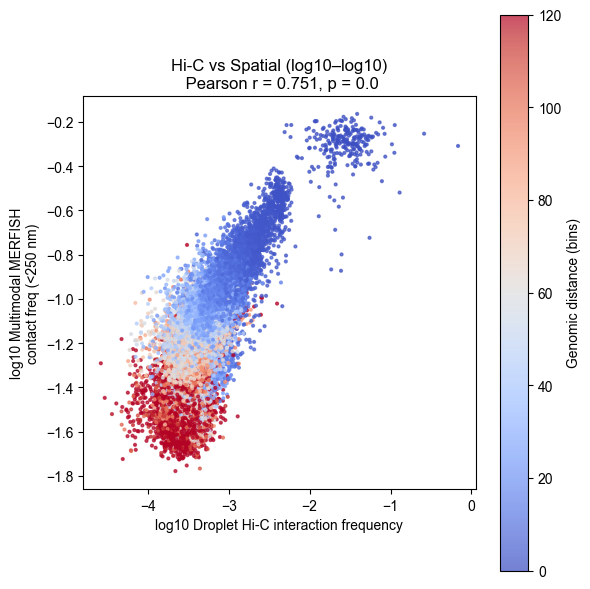

In [51]:
fig, ax, r = plot_hic_vs_spatial_log10(hic_mat = hic_mat, spatial_mat = D_circ_contact_freq, 
                    vmax_dist=120, plot_type = 'contact', log = True,
    # svg_path=r"C:/GBM39/manuscript_figures/invitro_fig1/plots/hic/BT__hic_vs_spatial_V2.svg",
    dots_dpi=600, s=4, alpha=0.7)


## compute median distance matrix

In [6]:
linear_meddist = np.nanmedian(compute_med_dist_mat(BT_linear_traces, contact_dist = None), axis = 0)
circ_meddist = np.nanmedian(compute_med_dist_mat(BT_circ_traces, contact_dist = None), axis = 0)

100%|██████████████████████████████████████████████████████████████████████████| 35969/35969 [00:09<00:00, 3666.55it/s]


## plot median distance matrix

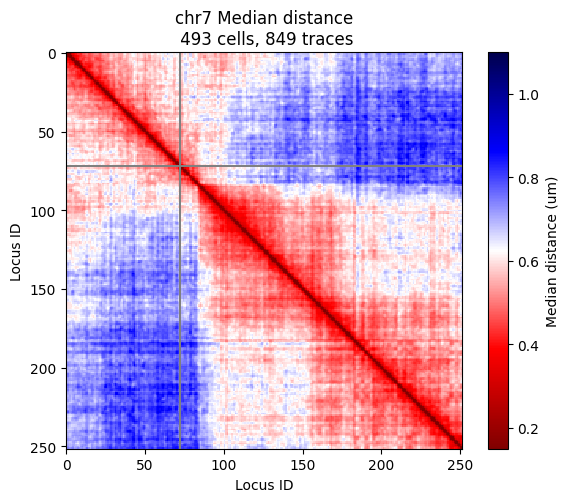

In [7]:
## chr7
ntrs = len(BT_linear_traces)
ncells = len(np.unique(np.nanmean(BT_linear_traces[:,:,-1], axis = 1)))

# --- Data & colormap with NaNs as dark gray ---
M0 = linear_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.15, vmax=1.1,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')

ax.set_title(f'chr7 Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()

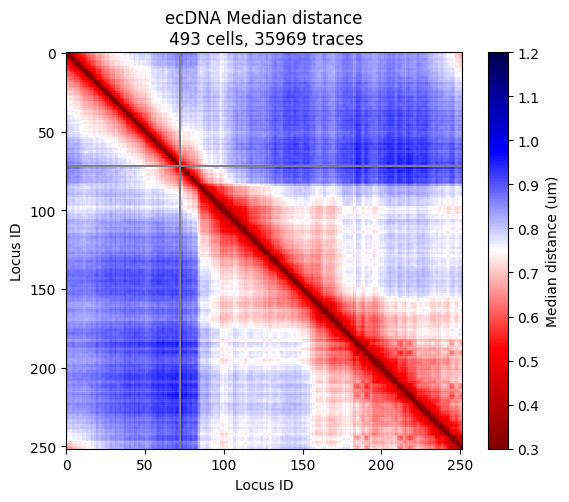

In [10]:
## ecDNA
ntrs = len(BT_circ_traces)
ncells = len(np.unique(np.nanmean(BT_circ_traces[:,:,-1], axis = 1)))

# --- Data & colormap with NaNs as dark gray ---
M0 = circ_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.3, vmax=1.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')
ax.set_title(f'ecDNA Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()

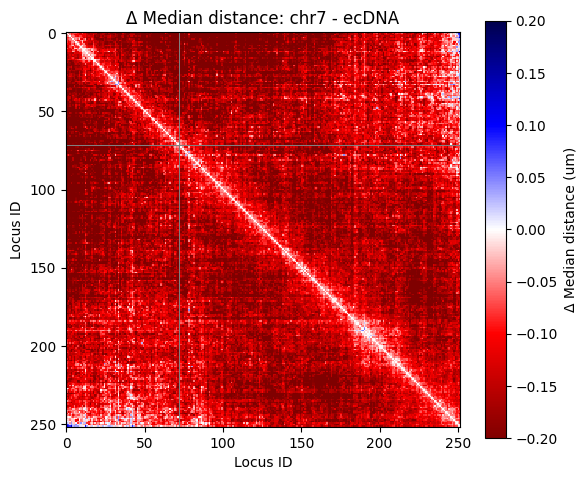

In [11]:
## difference matrix
# --- Data & colormap with NaNs as dark gray ---
Mdiff = linear_meddist - circ_meddist
M0 = cv2.blur(Mdiff, (2,2))
Mdiff[72, :] = np.NaN
Mdiff[:, 72] = np.NaN
cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(Mdiff, cmap=cmap, vmin=-0.2, vmax=0.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Median distance (um)')

ax.set_title(f'Δ Median distance: chr7 - ecDNA')

fig.tight_layout()

## radius of gyration

In [12]:
def get_rgs(coords_um):
    coords_um = np.array(coords_um)
    coords_um -= np.nanmean(coords_um, axis=0)[np.newaxis, :]  # center of mass
    distances = np.linalg.norm(coords_um, axis=-1)
    rg = np.sqrt(np.nanmean(distances ** 2))
    return rg

In [13]:
circ_all_rgs = [get_rgs(tr[:,:3]) for tr in BT_circ_traces]
lin_all_rgs = [get_rgs(tr[:,:3]) for tr in BT_linear_traces]

In [15]:
df_plot_violin = pd.DataFrame(lin_all_rgs+ circ_all_rgs, columns = ['rgs'])
df_plot_violin['is_circular'] = [0] * len(lin_all_rgs) + [1] * len(circ_all_rgs)
df_plot_violin

,rgs,is_circular
0,0.655719,0
1,0.518836,0
2,0.585255,0
3,0.533491,0
4,0.612887,0
...,...,...
36813,0.652002,1
36814,1.272979,1
36815,1.265202,1
36816,0.471146,1


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Radius of gyration:\nchr7 vs. ecDNA'}, ylabel='Radius of gyration (µm)'>,
             rgs  is_circular
 0      0.655719        False
 1      0.518836        False
 2      0.585255        False
 3      0.533491        False
 4      0.612887        False
 ...         ...          ...
 36813  0.652002         True
 36814  1.272979         True
 36815  1.265202         True
 36816  0.471146         True
 36817  0.534194         True
 
 [36818 rows x 2 columns],
 {'U': 9565534.0, 'p': 8.812756476219886e-78, 'q': None})

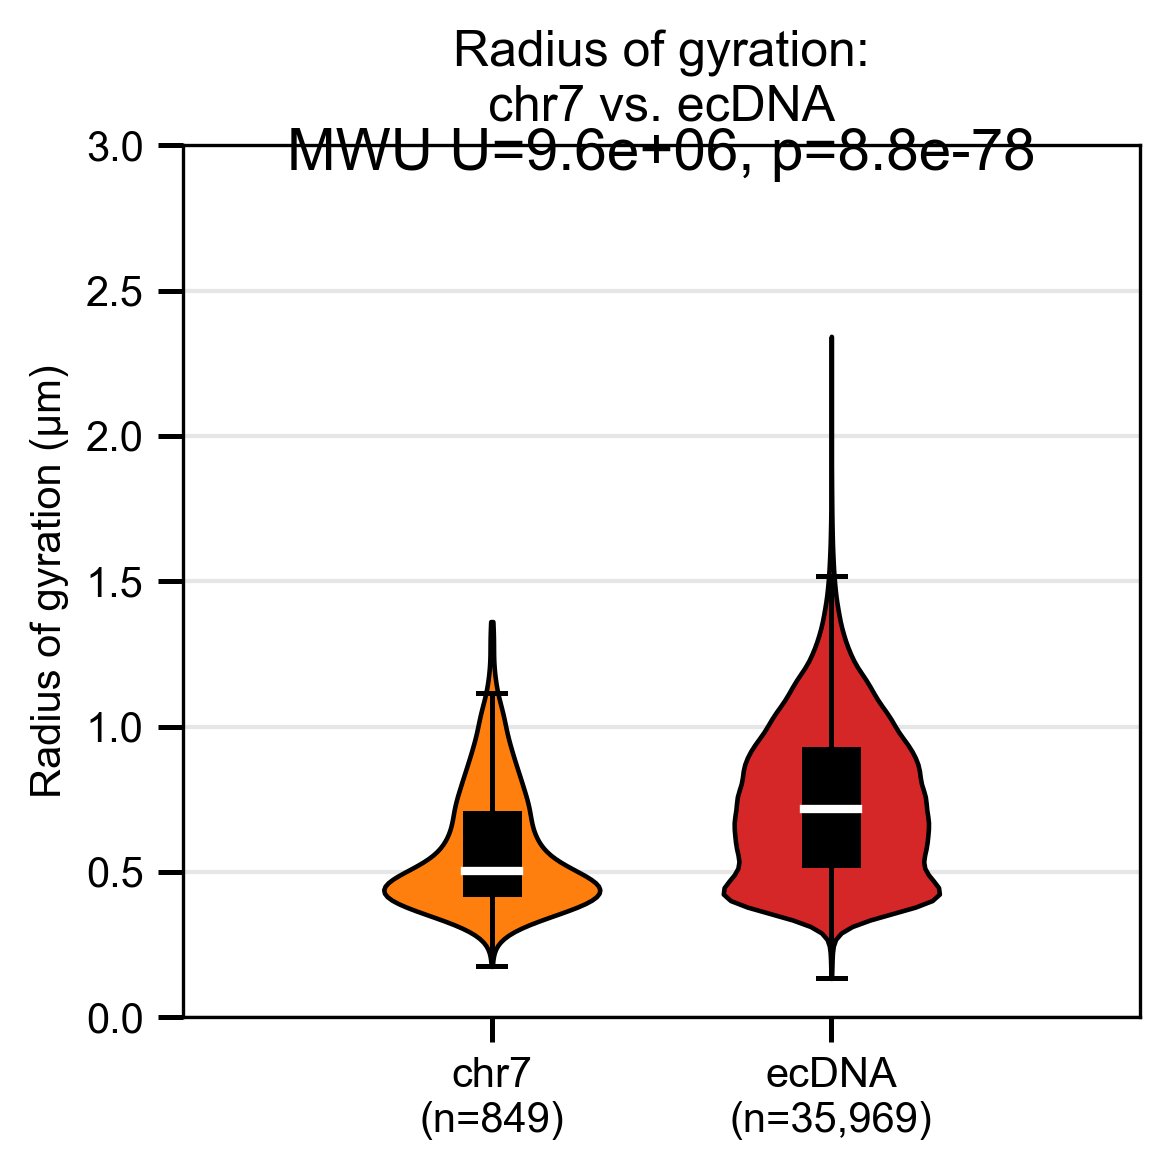

In [16]:
violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col='rgs',
    bool_col="is_circular",  # your boolean column
    order = (False, True),
    group_labels={True: "ecDNA", False: "chr7"},
    colors=("C1", "C3"),
    title="Radius of gyration:\nchr7 vs. ecDNA",
    y_label='Radius of gyration (µm)',
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="less", # "two-sided", "less"
    y_tick_step= 0.5,
    stats_fontsize=14,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
    # save_svg = r'C:/GBM39/manuscript_figures/invitro_fig1/plots/rgs/BT_chr7_vs_ecDNA_rgs_V3_MWU.svg',
)

# GBM39 in vitro replicate 2

## load traces

In [21]:
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_tracesBB_chromabb\TK__preEM_strict_redooffby1__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
TK_linear_traces, TK_circ_traces = dic_linear_circ_by_type[tr_type]
TK_linear_traces.shape, TK_circ_traces.shape

((214, 252, 6), (12491, 252, 6))

## compute detection efficiency

In [22]:
def compute_detection_eff(traces):
    detected = np.isfinite(traces)
    det_eff = detected.mean(axis=(0, 2))
    return det_eff

In [23]:
TK_det_eff_linear = compute_detection_eff(TK_linear_traces)
TK_det_eff_circ = compute_detection_eff(TK_circ_traces)

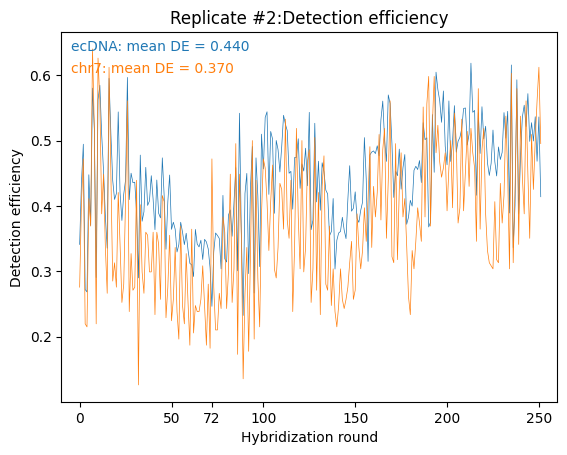

In [25]:
fig, ax = plt.subplots()

ax.plot(TK_det_eff_circ, color='C0', label='ecDNA', lw = 0.5)
ax.plot(TK_det_eff_linear, color='C1', label='chr7', lw = 0.5)

ax.set_xlabel('Hybridization round')
ax.set_ylabel('Detection efficiency')
ax.set_title('Replicate #2:Detection efficiency')

# x range
ax.set_xlim(0, 260)

# mean detection efficiencies
mean_circ = np.nanmean(TK_det_eff_circ)
mean_lin  = np.nanmean(TK_det_eff_linear)

# colored annotation (top-left)
ax.text(
    0.02, 0.98,
    f"ecDNA: mean DE = {mean_circ:.3f}",
    transform=ax.transAxes,
    ha='left', va='top',
    color='C0'
)
ax.text(
    0.02, 0.92,
    f"chr7: mean DE = {mean_lin:.3f}",
    transform=ax.transAxes,
    ha='left', va='top',
    color='C1'
)

# custom tick at 72
xticks = ax.get_xticks()
if 72 not in xticks:
    ax.set_xticks(sorted(np.append(xticks, 72)))
    

# remove legend
ax.legend().remove()

ax.set_xlim((-10, 260))
ax.margins(x=0)

plt.show()


## compute median distance matrix

In [26]:
linear_meddist = np.nanmedian(compute_med_dist_mat(TK_linear_traces, contact_dist = None), axis = 0)
circ_meddist = np.nanmedian(compute_med_dist_mat(TK_circ_traces, contact_dist = None), axis = 0)

100%|██████████████████████████████████████████████████████████████████████████| 12491/12491 [00:03<00:00, 3747.66it/s]


## plot median distance matrix

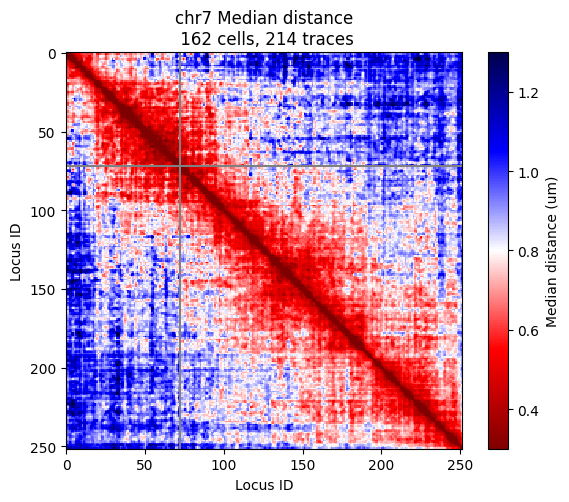

In [29]:
## chr7
ntrs = len(TK_linear_traces)
ncells = len(np.unique(np.nanmean(TK_linear_traces[:,:,-1], axis = 1)))
# --- Data & colormap with NaNs as dark gray ---
M0 = linear_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.3, vmax=1.3,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')

ax.set_title(f'chr7 Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()


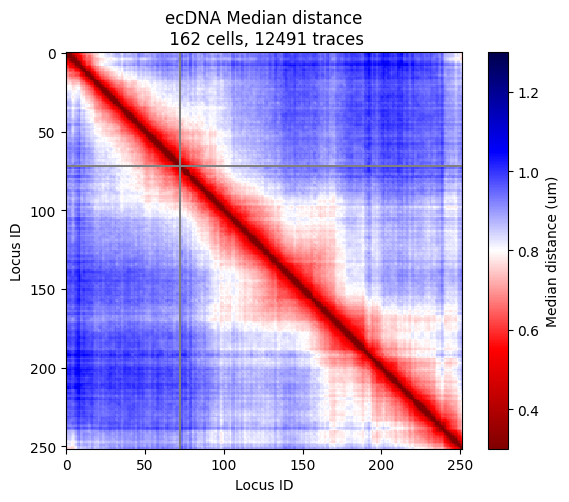

In [30]:
## ecDNA
ntrs = len(TK_circ_traces)
ncells = len(np.unique(np.nanmean(TK_circ_traces[:,:,-1], axis = 1)))

# --- Data & colormap with NaNs as dark gray ---
M0 = circ_meddist.copy()
M0 = cv2.blur(M0, (2,2))
M0[72, :] = np.NaN
M0[:, 72] = np.NaN


cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=0.3, vmax=1.3,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (um)')
ax.set_title(f'ecDNA Median distance\n {ncells} cells, {ntrs} traces')

fig.tight_layout()

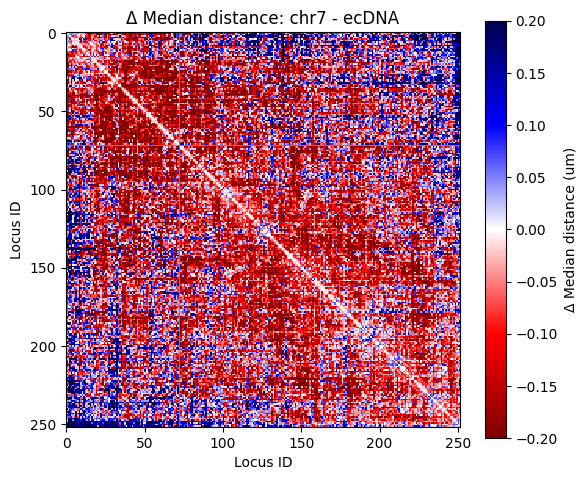

In [31]:
## difference matrix
# --- Data & colormap with NaNs as dark gray ---
Mdiff = linear_meddist - circ_meddist
M0 = cv2.blur(Mdiff, (2,2))
Mdiff[72, :] = np.NaN
Mdiff[:, 72] = np.NaN
cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(Mdiff, cmap=cmap, vmin=-0.2, vmax=0.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xlabel('Locus ID')
ax.set_ylabel('Locus ID')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Median distance (um)')

ax.set_title(f'Δ Median distance: chr7 - ecDNA')

fig.tight_layout()

## radius of gyration

In [32]:
def get_rgs(coords_um):
    coords_um = np.array(coords_um)
    coords_um -= np.nanmean(coords_um, axis=0)[np.newaxis, :]  # center of mass
    distances = np.linalg.norm(coords_um, axis=-1)
    rg = np.sqrt(np.nanmean(distances ** 2))
    return rg

In [33]:
circ_all_rgs = [get_rgs(tr[:,:3]) for tr in TK_circ_traces]
lin_all_rgs = [get_rgs(tr[:,:3]) for tr in TK_linear_traces]

In [34]:
df_plot_violin = pd.DataFrame(lin_all_rgs+ circ_all_rgs, columns = ['rgs'])
df_plot_violin['is_circular'] = [0] * len(lin_all_rgs) + [1] * len(circ_all_rgs)
df_plot_violin

,rgs,is_circular
0,1.009785,0
1,0.516087,0
2,1.007861,0
3,1.034416,0
4,0.524269,0
...,...,...
12700,1.040150,1
12701,0.982631,1
12702,0.628177,1
12703,0.816054,1


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Replicate 2 Radius of gyration:\nchr7 vs. ecDNA'}, ylabel='Radius of gyration (µm)'>,
             rgs  is_circular
 0      1.009785        False
 1      0.516087        False
 2      1.007861        False
 3      1.034416        False
 4      0.524269        False
 ...         ...          ...
 12700  1.040150         True
 12701  0.982631         True
 12702  0.628177         True
 12703  0.816054         True
 12704  0.734653         True
 
 [12705 rows x 2 columns],
 {'U': 1173858.0, 'p': 0.0011147947957055758, 'q': None})

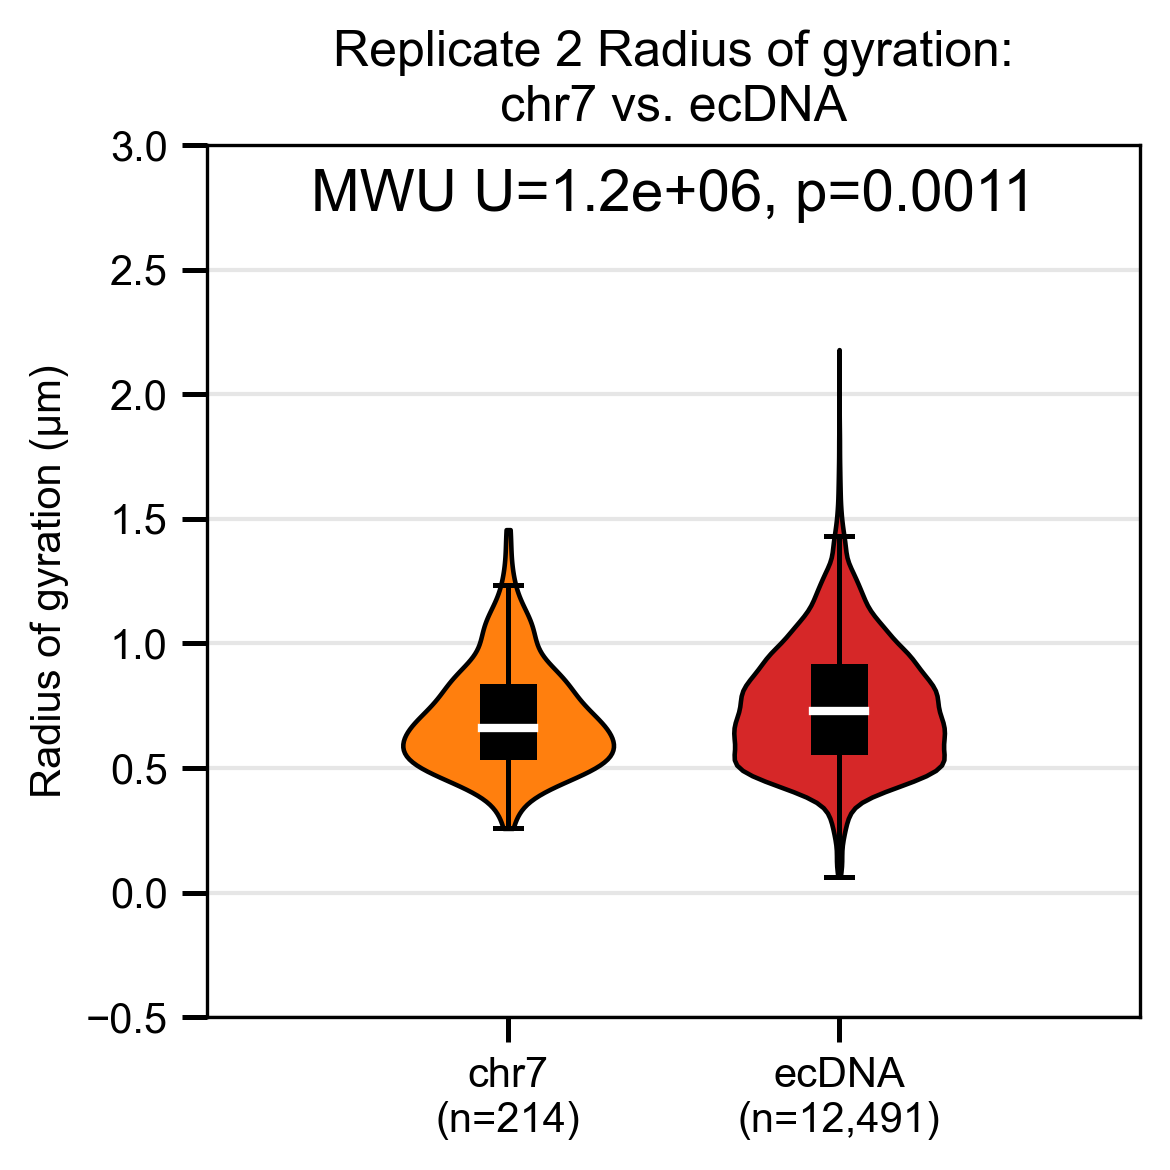

In [35]:
violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col='rgs',
    bool_col="is_circular",  # your boolean column
    order = (False, True),
    group_labels={True: "ecDNA", False: "chr7"},
    colors=("C1", "C3"),
    title="Replicate 2 Radius of gyration:\nchr7 vs. ecDNA",
    y_label='Radius of gyration (µm)',
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="less", # "two-sided", "less"
    y_tick_step= 0.5,
    stats_fontsize=14,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
    # save_svg = r'C:/GBM39/manuscript_figures/invitro_fig1/plots/rgs/BT_chr7_vs_ecDNA_rgs_V3_MWU.svg',
)

## replicate correlation

In [38]:
TK_joint_traces = np.vstack([TK_linear_traces, TK_circ_traces])
TK_joint_meddist = np.nanmedian(compute_med_dist_mat(TK_joint_traces, contact_dist = None), axis = 0)

100%|██████████████████████████████████████████████████████████████████████████| 12705/12705 [00:03<00:00, 3740.60it/s]


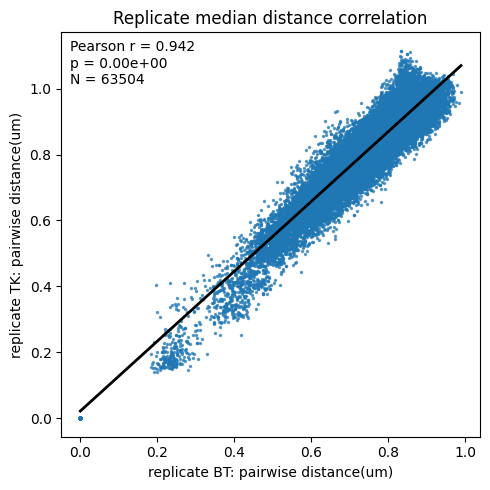

In [40]:
r, p = scatter_matrix_entries(
    BT_joint_meddist,
    TK_joint_meddist,
    xlabel="replicate BT: pairwise distance(um)",
    ylabel="replicate TK: pairwise distance(um)",
    title="Replicate median distance correlation",
    s= 2,
    # save_svg= r"C:/GBM39/manuscript_figures/extended_invitro_fig1/plots/replicateTK/TK_vs_BT_med_dist_corr.svg"
)
